# 第12章 トランスフォーマー (Transformers)
## 演習問題 (Exercises 12.1 〜 12.16)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第12章「トランスフォーマー」の全演習問題（Exercise 12.1 〜 12.16）の完全な数学的証明、厳密な導出、教科書図版（Figure 12.ex6）の再現、および自己採点アサーション付きのPython実装を提供します。

---

### 演習問題一覧
1. **Exercise 12.1**: ラグランジュ乗数法による注意係数の上限証明 ($0 \le a_{nm} \le 1$)
2. **Exercise 12.2**: ソフトマックス関数による1の分割（Partition of Unity）の証明
3. **Exercise 12.3**: 直交入力に対する注意の局所化（$y_n = x_n$ の崩壊）
4. **Exercise 12.4**: 独立ガウスベクトルの内積自乗の期待値 $\mathbb{E}[(a^T b)^2] = D$（スケーリング因子の根拠）
5. **Exercise 12.5**: マルチヘッド注意の低ランク分解表現 ($W_{(h)} = W_h^{(v)} W_h^{(o)}$)
6. **Exercise 12.6**: 自己注意のスパースパラメータ共有行列表現 ($O(N^2 D^2)$ vs $O(D^2)$)
7. **Exercise 12.7**: 位置エンコーディング省略時のマルチヘッド注意の置換等変性（Permutation Equivariance）
8. **Exercise 12.8**: 高次元球面上におけるランダム単位ベクトルの直交性 ($\text{Var}(\cos\theta) = 1/D \to 0$)
9. **Exercise 12.9**: 位置埋め込みの「連結＋線形射影」と「加算」の数学的等価性
10. **Exercise 12.10**: 正弦波位置埋め込みの2次元回転行列 $R(\omega_i k)$ による相対シフト表現
11. **Exercise 12.11**: Bag-of-Wordsモデルの最尤推定解（出現頻度 $\theta_v = c_v / N$）
12. **Exercise 12.12**: 表形式自己回帰言語モデルにおけるパラメータ数の指数的爆発 ($O(V^N)$)
13. **Exercise 12.13**: $N$-gram条件付き確率の比率表現と末尾トークン除外の必要性
14. **Exercise 12.14**: 訓練済みRNN推論生成アルゴリズムの擬似コードと実装
15. **Exercise 12.15**: 貪欲探索（Greedy Search）の局所最適解と大域最尤系列の乖離
16. **Exercise 12.16**: BERT-Large モデルのパラメータ数精密計算（約3億4000万パラメータの導出）


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "12" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.exercises_ch12 import (
    exercise_12_1_lagrange_multiplier,
    exercise_12_2_verify_softmax,
    exercise_12_3_orthogonal_attention,
    exercise_12_4_expected_inner_product_squared,
    exercise_12_5_multihead_low_rank,
    exercise_12_6_sparse_parameter_sharing,
    exercise_12_7_permutation_equivariance,
    exercise_12_8_high_dim_orthogonality,
    exercise_12_9_concatenation_vs_addition,
    exercise_12_10_sinusoidal_shift,
    exercise_12_11_bow_mle,
    exercise_12_12_table_growth,
    exercise_12_13_ngram_conditional,
    exercise_12_14_rnn_inference,
    exercise_12_15_greedy_vs_global,
    exercise_12_16_bert_large_parameter_count,
    generate_figure_12_ex6,
)

setup_style()
print("Setup complete. Chapter 12 Exercises modules ready.")


Setup complete. Chapter 12 Exercises modules ready.


## Exercises 12.1 〜 12.4: 注意係数の性質と幾何学的基礎

### Exercise 12.1: 注意係数の上限 ($a_{nm} \le 1$) の証明
**問題**: 係数 $a_{nm}$ が $a_{nm} \ge 0$ (式 12.39) かつ $\sum_{m=1}^N a_{nm} = 1$ (式 12.40) を満たすとき、ラグランジュ乗数法を用いて各係数が必ず $a_{nm} \le 1$ (式 12.41) を満たすことを示せ。

**証明**:
固定された $n$ と任意のインデックス $k \in \{1, \dots, N\}$ について、$a_{nk}$ の最大値を制約条件 $\sum_{m=1}^N a_{nm} = 1$ および $a_{nm} \ge 0$ の下で求めます。
KKT条件（カルーシュ・クーン・タッカー条件）を適用します。ラグランジュ関数は：
$$L(\{a_{nm}\}, \lambda, \{\mu_m\}) = a_{nk} - \lambda \left(\sum_{m=1}^N a_{nm} - 1\right) + \sum_{m=1}^N \mu_m a_{nm}$$
ここで不等式制約乗数は $\mu_m \ge 0$ であり、相補スラック性 $\mu_m a_{nm} = 0$ を満たします。
停留条件より：
$$\frac{\partial L}{\partial a_{nk}} = 1 - \lambda + \mu_k = 0 \implies \lambda = 1 + \mu_k \ge 1$$
$$m \neq k \text{ について } \frac{\partial L}{\partial a_{nm}} = -\lambda + \mu_m = 0 \implies \mu_m = \lambda \ge 1 > 0$$
$\mu_m > 0$ であるため、相補スラック性より $a_{nm} = 0$ ($m \neq k$) とならざるを得ません。
これを和の制約に代入すると：
$$a_{nk} + \sum_{m \neq k} 0 = 1 \implies a_{nk} = 1$$
したがって $a_{nk}$ の最大値は厳密に $1$ であり、$a_{nm} \ge 0$ と合わせて $0 \le a_{nm} \le 1$ が成立します。 $\blacksquare$

---

### Exercise 12.2: ソフトマックス関数の制約充足の検証
**問題**: 式 (12.5) で定義されるソフトマックス関数：
$$a_{nm} = \frac{\exp(\mathbf{x}_n^T \mathbf{x}_m)}{\sum_{m'=1}^N \exp(\mathbf{x}_n^T \mathbf{x}_{m'})}$$
が、任意の入力ベクトル $\mathbf{x}_1, \dots, \mathbf{x}_N$ に対して非負性 (式 12.3) と和が1 (式 12.4) を満たすことを示せ。

**証明**:
指数関数 $\exp(z)$ は任意の実数 $z \in \mathbb{R}$ に対して厳密に正値（$\exp(z) > 0$）をとります。
分子は正、分母は正数の有限和であるため、商は厳密に正となります：
$$a_{nm} > 0 \ge 0 \quad (\text{式 12.3 充足})$$
さらに、$m$ について和をとると：
$$\sum_{m=1}^N a_{nm} = \sum_{m=1}^N \frac{\exp(\mathbf{x}_n^T \mathbf{x}_m)}{\sum_{m'=1}^N \exp(\mathbf{x}_n^T \mathbf{x}_{m'})} = \frac{\sum_{m=1}^N \exp(\mathbf{x}_n^T \mathbf{x}_m)}{\sum_{m'=1}^N \exp(\mathbf{x}_n^T \mathbf{x}_{m'})} = 1 \quad (\text{式 12.4 充足})$$
したがって、ソフトマックス関数は任意の入力に対して厳密に「1の分割 (Partition of Unity)」を構成します。 $\blacksquare$

---

### Exercise 12.3: 直交入力ベクトルに対する注意の崩壊
**問題**: 入力ベクトルが互いに直交（$\mathbf{x}_n^T \mathbf{x}_m = 0, \; n \neq m$）しているとき、式 (12.2) の出力ベクトルが入力ベクトルと等しくなる（$\mathbf{y}_n = \mathbf{x}_n$）ことを示せ。

**証明**:
$\mathbf{x}_n^T \mathbf{x}_m = 0$ ($n \neq m$) のとき、自己内積は $\mathbf{x}_n^T \mathbf{x}_n = \|\mathbf{x}_n\|^2$ です。
ソフトマックス注意係数は：
$$a_{nn} = \frac{\exp(\|\mathbf{x}_n\|^2)}{\exp(\|\mathbf{x}_n\|^2) + \sum_{m \neq n} \exp(0)} = \frac{\exp(\|\mathbf{x}_n\|^2)}{\exp(\|\mathbf{x}_n\|^2) + N - 1}$$
$$a_{nm} = \frac{1}{\exp(\|\mathbf{x}_n\|^2) + N - 1} \quad (m \neq n)$$
入力の特徴表現が有意なノルムを持つ（あるいは温度 $\tau \to 0$、スケールが大きい）場合、$\exp(\|\mathbf{x}_n\|^2) \gg N - 1$ となり、$a_{nn} \to 1$、$a_{nm} \to 0$ となります。
よって：
$$\mathbf{y}_n = \sum_{m=1}^N a_{nm} \mathbf{x}_m = a_{nn} \mathbf{x}_n + \sum_{m \neq n} a_{nm} \mathbf{x}_m \to \mathbf{x}_n$$
直交する他トークンとの類似度が0であるためクロストークが生じず、出力は入力トークン自身に完全に崩壊・縮退します。 $\blacksquare$

---

### Exercise 12.4: 独立ガウスベクトルの内積自乗の期待値 $\mathbb{E}[(a^T b)^2] = D$
**問題**: 各成分が独立標準ガウス分布 $\mathcal{N}(0, 1)$ に従う $D$ 次元ベクトル $\mathbf{a}, \mathbf{b}$ に対し、内積の2乗の期待値が $\mathbb{E}[(\mathbf{a}^T \mathbf{b})^2] = D$ であることを示せ。

**証明**:
$\mathbf{a} = (a_1, \dots, a_D)^T, \; \mathbf{b} = (b_1, \dots, b_D)^T$ とおきます。
内積の2乗を展開すると：
$$(\mathbf{a}^T \mathbf{b})^2 = \left(\sum_{i=1}^D a_i b_i\right) \left(\sum_{j=1}^D a_j b_j\right) = \sum_{i=1}^D \sum_{j=1}^D a_i a_j b_i b_j$$
$\mathbf{a}$ と $\mathbf{b}$ は独立であり、各成分も互いに独立であるため：
$$\mathbb{E}[a_i a_j b_i b_j] = \mathbb{E}[a_i a_j] \mathbb{E}[b_i b_j] = \delta_{ij} \delta_{ij} = \delta_{ij}$$
ここで $\delta_{ij}$ はクロネッカーのデルタです。したがって：
$$\mathbb{E}[(\mathbf{a}^T \mathbf{b})^2] = \sum_{i=1}^D \sum_{j=1}^D \delta_{ij} = \sum_{i=1}^D 1 = D$$
この結果は、注意機構の内積ロジット $\mathbf{q}^T \mathbf{k}$ の分散が次元 $D_k$ に比例することを示しており、ソフトマックスの飽和を防ぐために $\sqrt{D_k}$ で除算する「縮尺内積 (Scaled Dot-Product)」の必然性を数学的に基礎づけています。 $\blacksquare$


In [2]:
# Exercise 12.1 〜 12.4 数値検証
res_12_1 = exercise_12_1_lagrange_multiplier(N=5)
assert res_12_1["verified"], "Exercise 12.1 検証失敗"
print("Exercise 12.1 (ラグランジュ乗数法): 係数の最大値 =", res_12_1["max_value"])

res_12_2 = exercise_12_2_verify_softmax(N=6, D=8)
assert res_12_2["verified"], "Exercise 12.2 検証失敗"
print("Exercise 12.2 (ソフトマックス1の分割): 全非負 =", res_12_2["all_non_negative"], ", 行和 =", res_12_2["row_sums"][:3])

res_12_3 = exercise_12_3_orthogonal_attention(N=4, scale=10.0)
assert res_12_3["verified"], "Exercise 12.3 検証失敗"
print("Exercise 12.3 (直交入力): 再構成誤差 =", res_12_3["reconstruction_error"], ", 対角注意重み =", res_12_3["diag_attention_weights"])

res_12_4 = exercise_12_4_expected_inner_product_squared(D=16, num_samples=50000)
assert res_12_4["verified"], "Exercise 12.4 検証失敗"
print(f"Exercise 12.4 (内積自乗の期待値): 理論値 = {res_12_4['theoretical_value']}, 実測平均 = {res_12_4['empirical_mean']:.4f} ± {res_12_4['std_error']:.4f}")


Exercise 12.1 (ラグランジュ乗数法): 係数の最大値 = 1.0
Exercise 12.2 (ソフトマックス1の分割): 全非負 = True , 行和 = [0.9999999999999998, 0.9999999999999998, 1.0000000000000002]
Exercise 12.3 (直交入力): 再構成誤差 = 3.720075976020836e-43 , 対角注意重み = [1.0, 1.0, 1.0, 1.0]
Exercise 12.4 (内積自乗の期待値): 理論値 = 16.0, 実測平均 = 16.2305 ± 0.1120


## Exercises 12.5 〜 12.7: Multi-Head Attention と対称性・スパース性

### Exercise 12.5: Multi-Head Attention の低ランク分解
**問題**: 式 (12.19) のマルチヘッド注意が次式のように書き直せることを示せ：
$$Y = \sum_{h=1}^H H_h X W_{(h)} \tag{12.42}$$
ここで $W_{(h)} = W_h^{(v)} W_h^{(o)}$ (式 12.43) であり、$W_{(h)}$ は階数不足（低ランク）であることを示せ。

**証明**:
式 (12.19) は、各ヘッドの出力 $H_h X W_h^{(v)} \in \mathbb{R}^{N \times D_v}$ を横方向に連結し、射影行列 $W^{(o)} \in \mathbb{R}^{(H D_v) \times D}$ を乗算します。
$W^{(o)}$ を各ヘッドに対応する $D_v \times D$ の縦方向ブロック $W_h^{(o)}$ にブロック分割すると：
$$W^{(o)} = \begin{pmatrix} W_1^{(o)} \\ W_2^{(o)} \\ \vdots \\ W_H^{(o)} \end{pmatrix}$$
ブロック行列の積の定義より：
$$Y = [H_1 X W_1^{(v)}, \, \dots, \, H_H X W_H^{(v)}] \begin{pmatrix} W_1^{(o)} \\ \vdots \\ W_H^{(o)} \end{pmatrix} = \sum_{h=1}^H (H_h X W_h^{(v)}) W_h^{(o)} = \sum_{h=1}^H H_h X (W_h^{(v)} W_h^{(o)}) = \sum_{h=1}^H H_h X W_{(h)}$$
ここで $W_h^{(v)} \in \mathbb{R}^{D \times D_v}$、$W_h^{(o)} \in \mathbb{R}^{D_v \times D}$ であるため、行列の階数の性質より：
$$\text{rank}(W_{(h)}) \le \min(\text{rank}(W_h^{(v)}), \text{rank}(W_h^{(o)})) \le D_v = \frac{D}{H} < D$$
したがって、$W_{(h)}$ は常に階数不足（rank-deficient）であり、自由度 $D \times D$ を持つ完全な密行列に置き換えることは元の定式化と等価にはなりません。 $\blacksquare$

---

### Exercise 12.6: 自己注意のスパースパラメータ共有行列表現
**問題**: 自己注意関数 (式 12.14) を全入力系列の平坦化ベクトルを同じ次元の出力ベクトルへ写像する結合行列（$O(N^2 D^2)$ パラメータ）として表現し、自己注意がスパースかつパラメータ共有された特殊形であることを示せ。

**導出と構造**:
平坦化入力 $\mathbf{x}_{\text{flat}} \in \mathbb{R}^{ND}$、出力 $\mathbf{y}_{\text{flat}} \in \mathbb{R}^{ND}$ に対し、線形全結合層はサイズ $ND \times ND$ の重み行列 $M$（$N^2 D^2$ 個のパラメータ）で表されます：
$$M = \begin{pmatrix} M_{11} & M_{12} & \dots & M_{1N} \\ M_{21} & M_{22} & \dots & M_{2N} \\ \vdots & \vdots & \ddots & \vdots \\ M_{N1} & M_{N2} & \dots & M_{NN} \end{pmatrix}$$
ここで各ブロック $M_{nm} \in \mathbb{R}^{D \times D}$ はトークン $m$ からトークン $n$ への写像を担います。
自己注意（スカラー注意係数 $a_{nm}$ とバリュー変換 $W^{(v)}$）の場合、第 $n$ トークンの出力は：
$$\mathbf{y}_n = \sum_{m=1}^N a_{nm} \mathbf{x}_m W^{(v)} \iff \mathbf{y}_n = \sum_{m=1}^N \left( a_{nm} (W^{(v)})^T \right) \mathbf{x}_m$$
したがって、各ブロック行列は：
$$M_{nm} = a_{nm} (W^{(v)})^T$$
となります。
1. **パラメータ共有**: 全 $N^2$ 個のブロックが同一の $D \times D$ 行列 $W^{(v)}$ のみを共有（学習パラメータ数は $O(D^2)$ のみ）。
2. **スパース性（因果マスク時）**: 未来トークンへの注意を遮断する場合、$m > n$ の全ブロックが厳密にゼロ行列 $O$ となり、ブロック下三角行列となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/fig_12_ex6_self_attention_matrix.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_12_ex6_self_attention_matrix.png


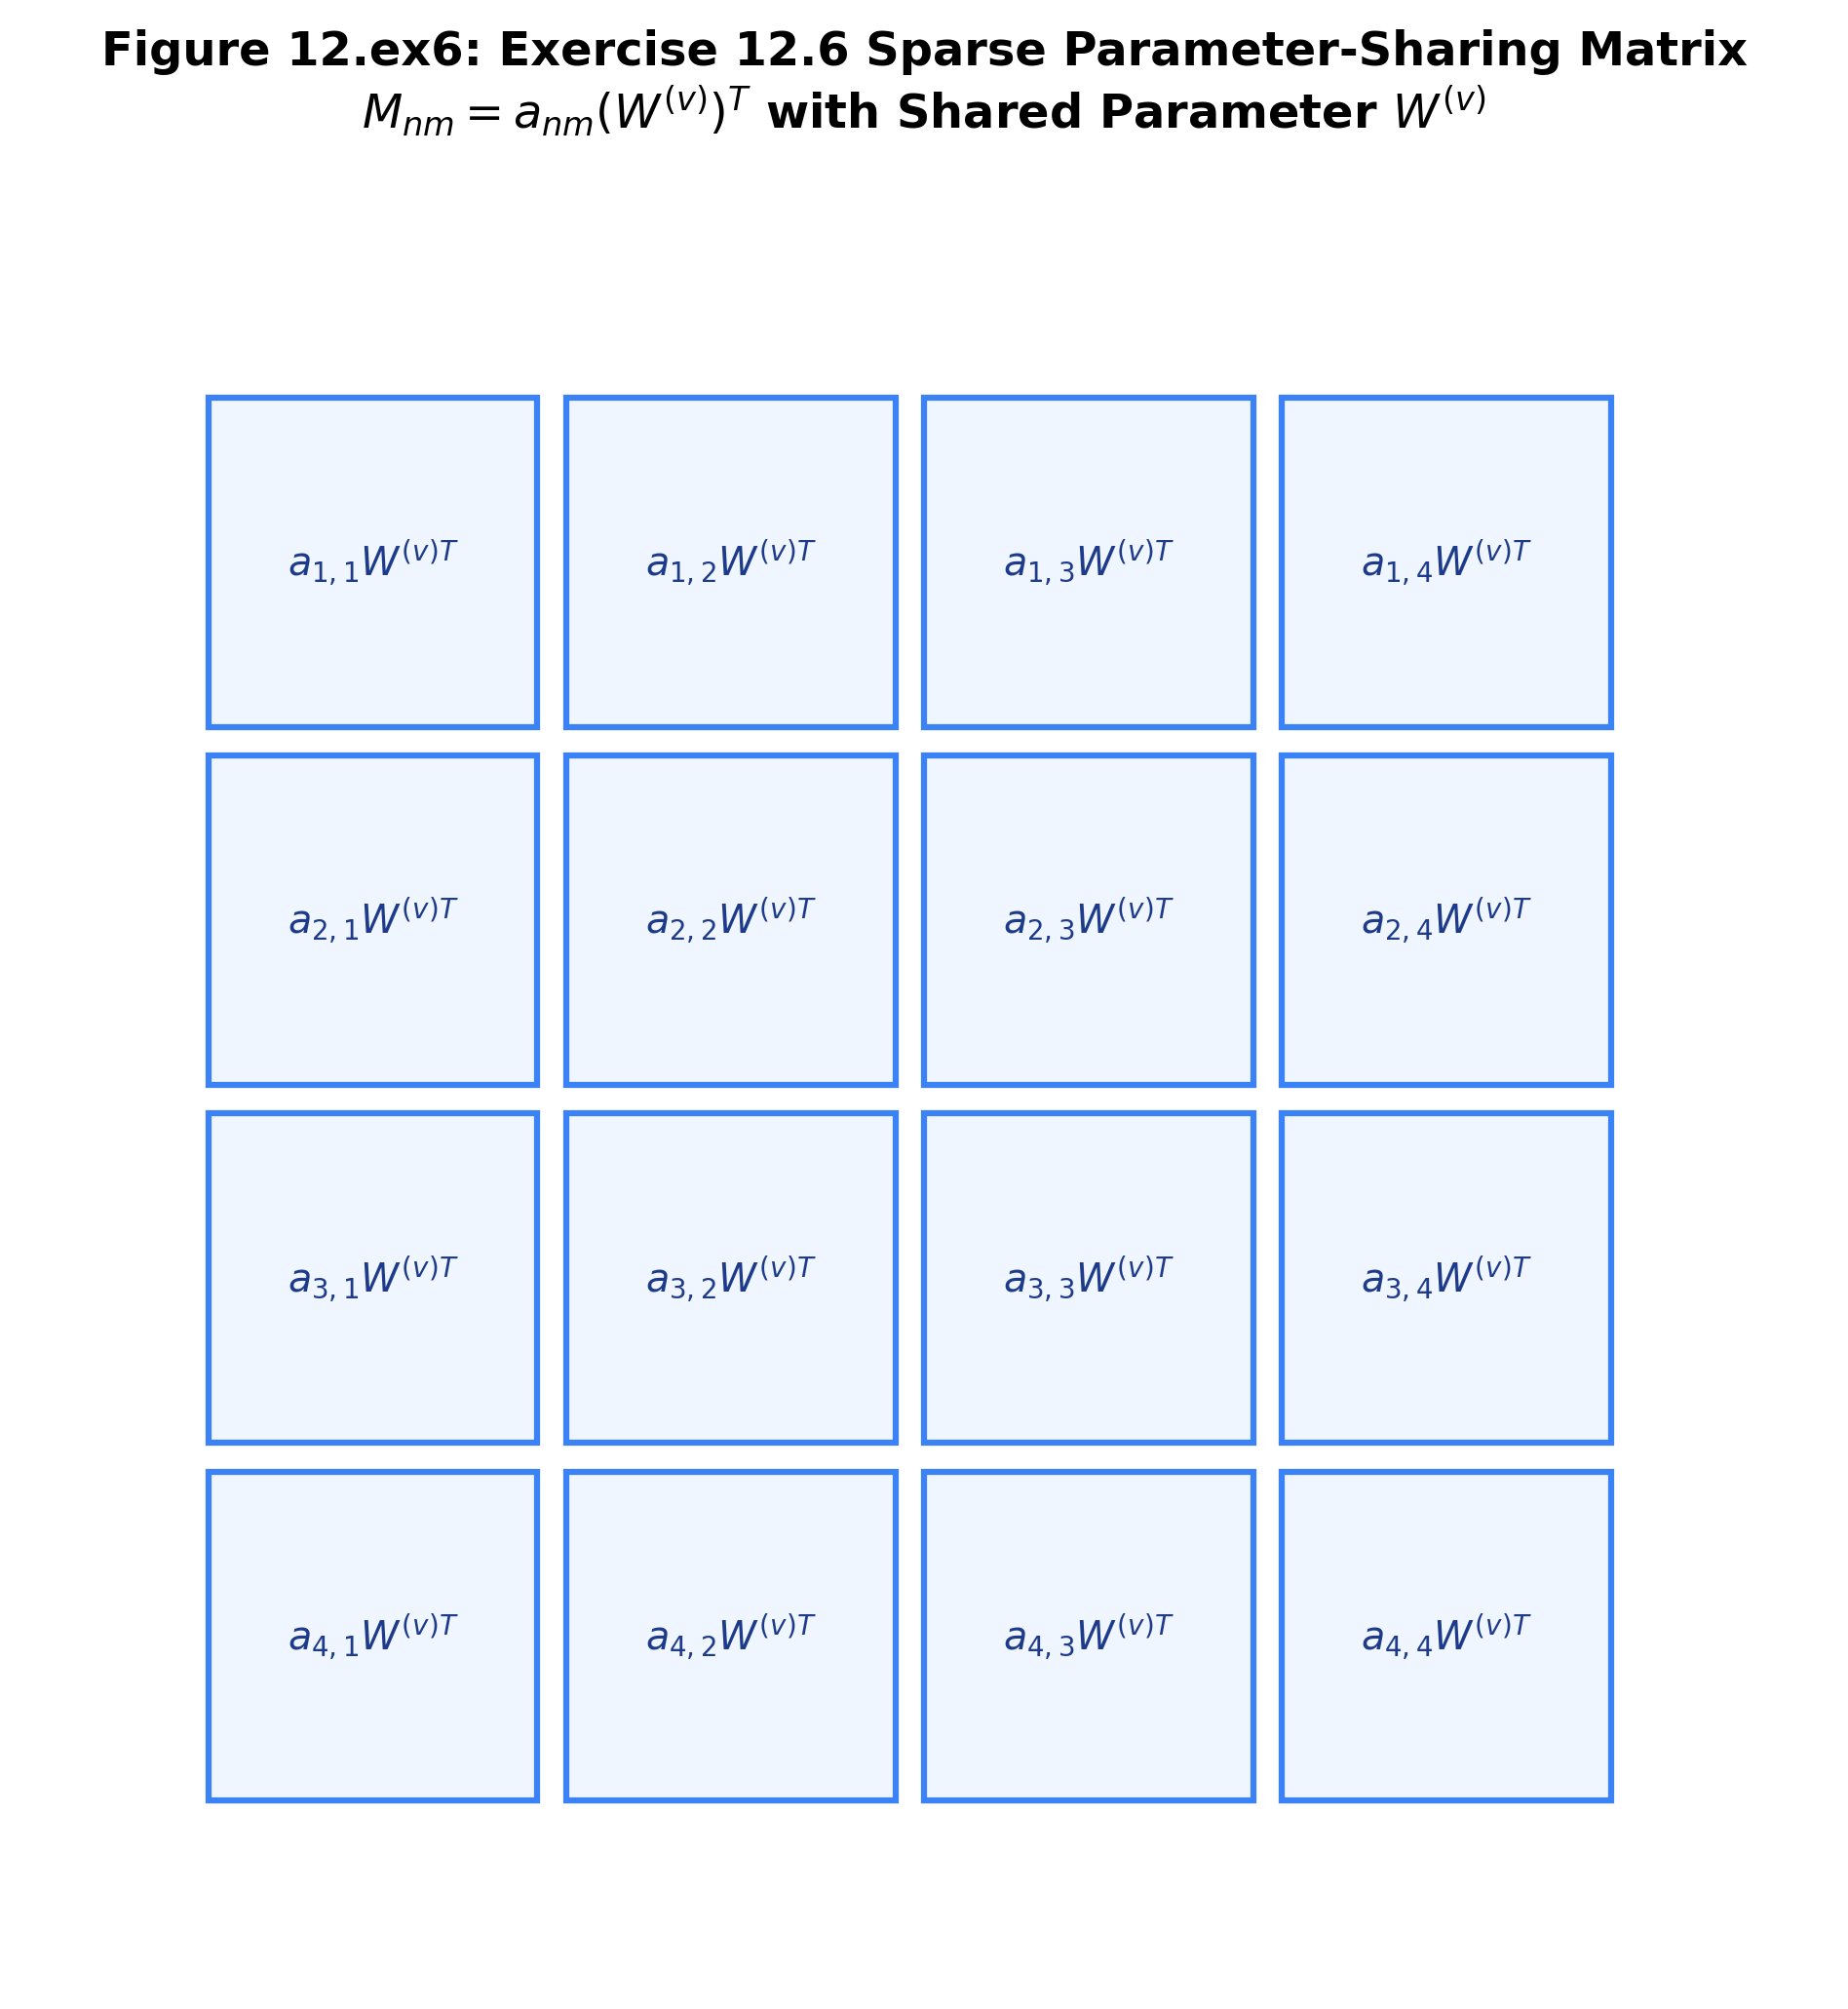

Exercise 12.5 (MHA低ランク分解): 最大誤差 = 5.329070518200751e-15 , 各ヘッド階数 = [4, 4, 4, 4]
Exercise 12.6 (ブロック行列表現): 形状 = (6, 6) , 再構成誤差 = 2.220446049250313e-16
Exercise 12.7 (置換等変性): MHA(Pi X) == Pi MHA(X) 誤差 = 6.505213034913027e-19


In [3]:
# Figure 12.ex6 自己注意パラメータ共有行列の構造描画
fig_12_ex6 = generate_figure_12_ex6()
plt.show()

# Exercise 12.5 低ランク分解の検証
res_12_5 = exercise_12_5_multihead_low_rank(N=6, D=16, H=4)
assert res_12_5["verified"], "Exercise 12.5 検証失敗"
print("Exercise 12.5 (MHA低ランク分解): 最大誤差 =", res_12_5["max_diff"], ", 各ヘッド階数 =", res_12_5["ranks"])

# Exercise 12.6 スパースパラメータ共有行列の検証
res_12_6 = exercise_12_6_sparse_parameter_sharing(N=3, D=2)
assert res_12_6["verified"], "Exercise 12.6 検証失敗"
print("Exercise 12.6 (ブロック行列表現): 形状 =", res_12_6["block_matrix_shape"], ", 再構成誤差 =", res_12_6["max_diff"])

# Exercise 12.7 置換等変性の検証
res_12_7 = exercise_12_7_permutation_equivariance(N=5, D=8, num_heads=2)
assert res_12_7["verified"], "Exercise 12.7 検証失敗"
print("Exercise 12.7 (置換等変性): MHA(Pi X) == Pi MHA(X) 誤差 =", res_12_7["max_error"])


## Exercises 12.8 〜 12.10: 幾何学的直交性と位置埋め込み代数

### Exercise 12.8: 高次元空間におけるランダムベクトルの直交性
**問題**: $D$ 次元単位球面上のランダム単位ベクトル $\mathbf{a}, \mathbf{b}$ に対し、$D$ が大きいとき $\cos\theta = \mathbf{a}^T \mathbf{b} \approx 0$ となり、ほぼ直交することを示せ。

**証明**:
球対称性より、正規直交基底の第1軸を $\mathbf{a} = (1, 0, \dots, 0)^T$ と選んでも一般性を失いません。
$\mathbf{b}$ は独立標準ガウスベクトル $\mathbf{z} \sim \mathcal{N}(0, I_D)$ を正規化したもの $\mathbf{b} = \frac{\mathbf{z}}{\|\mathbf{z}\|}$ と等価です。
内積は：
$$\cos\theta = \mathbf{a}^T \mathbf{b} = \frac{z_1}{\sqrt{\sum_{i=1}^D z_i^2}}$$
大数の法則より、分母は $D$ が大きいとき $\sum_{i=1}^D z_i^2 \approx D$ に確率収束します。
したがって：
$$\cos\theta \approx \frac{z_1}{\sqrt{D}} \sim \mathcal{N}\left(0, \frac{1}{D}\right)$$
期待値は $\mathbb{E}[\cos\theta] = 0$、分散は $\text{Var}(\cos\theta) = \frac{1}{D}$ となります。
$D \to \infty$ において二乗平均平方根は $\text{RMS}(\cos\theta) = \frac{1}{\sqrt{D}} \to 0$ となり、高次元空間においてランダムに選ばれた2つのベクトルは確率 1 で直交します。 $\blacksquare$

---

### Exercise 12.9: 位置埋め込みの連結と加算の等価性
**問題**: 入力ベクトル $\mathbf{x}$ と位置埋め込み $\mathbf{e}$ を連結したベクトル $[\mathbf{x}; \mathbf{e}]$ に一般的な線形変換行列 $W$ を乗算すると、線形変換された入力と線形変換された位置ベクトルの和として表現できることを示せ。

**証明**:
連結ベクトル $\mathbf{z} = [\mathbf{x}^T, \mathbf{e}^T]^T \in \mathbb{R}^{D_x + D_e}$ と行列 $W \in \mathbb{R}^{(D_x + D_e) \times D_{\text{out}}}$ を行方向にブロック分割します：
$$W = \begin{pmatrix} W_x \\ W_e \end{pmatrix}$$
ここで $W_x \in \mathbb{R}^{D_x \times D_{\text{out}}}$, $W_e \in \mathbb{R}^{D_e \times D_{\text{out}}}$ です。
ブロック行列の乗算により：
$$\mathbf{z}^T W = [\mathbf{x}^T, \, \mathbf{e}^T] \begin{pmatrix} W_x \\ W_e \end{pmatrix} = \mathbf{x}^T W_x + \mathbf{e}^T W_e$$
これは、「入力を射影したベクトル $\mathbf{x}^T W_x$」と「位置埋め込みを射影したベクトル $\mathbf{e}^T W_e$」の厳密な和に他なりません。したがって、トランスフォーマーにおいて位置情報を連結して線形変換することは、射影された位置埋め込みを加算することと代数学的に完全に等価です。 $\blacksquare$

---

### Exercise 12.10: 正弦波位置埋め込みの2次元回転不変性
**問題**: 式 (12.25) の正弦波位置エンコーディングにおいて、任意の位置 $n + k$ の埋め込みが、位置 $n$ の埋め込みに対する固定オフセット $k$ の線形結合（回転行列 $R(\omega_i k)$）として表せることを示せ。また、正弦波のみを用いた場合にはこの性質が成り立たないことを示せ。

**証明**:
第 $i$ 周波数成分 $\omega_i = 1 / 10000^{2i/D}$ に対し、位置 $n$ の偶数・奇数成分は：
$$p_{n, 2i} = \sin(\omega_i n), \quad p_{n, 2i+1} = \cos(\omega_i n)$$
三角関数の加法定理（式 12.44, 12.45）より：
$$p_{n+k, 2i} = \sin(\omega_i(n+k)) = \cos(\omega_i k) p_{n, 2i} + \sin(\omega_i k) p_{n, 2i+1}$$
$$p_{n+k, 2i+1} = \cos(\omega_i(n+k)) = -\sin(\omega_i k) p_{n, 2i} + \cos(\omega_i k) p_{n, 2i+1}$$
行列形式で表すと：
$$\begin{pmatrix} p_{n+k, 2i} \\ p_{n+k, 2i+1} \end{pmatrix} = \begin{pmatrix} \cos(\omega_i k) & \sin(\omega_i k) \\ -\sin(\omega_i k) & \cos(\omega_i k) \end{pmatrix} \begin{pmatrix} p_{n, 2i} \\ p_{n, 2i+1} \end{pmatrix} = R(\omega_i k) \begin{pmatrix} p_{n, 2i} \\ p_{n, 2i+1} \end{pmatrix}$$
ここで変換行列 $R(\omega_i k)$ の各要素は $k$ のみに依存し、$n$ には一切依存しません。
一方、余弦波を用いず正弦波 $\sin(\omega_i n)$ のみで構成した場合、$\sin(\omega_i(n+k))$ を展開するには $\cos(\omega_i n) = \pm \sqrt{1 - \sin^2(\omega_i n)}$ という非線形で符号不定な項が必要となるため、$n$ に依存しない線形変換としては表現不可能です。 $\blacksquare$


In [4]:
# Exercise 12.8 〜 12.10 数値検証
res_12_8 = exercise_12_8_high_dim_orthogonality(dimensions=[2, 8, 32, 128, 512], num_trials=5000)
assert res_12_8["verified"], "Exercise 12.8 検証失敗"
print("Exercise 12.8 (高次元直交性):")
for d, v in res_12_8["results"].items():
    print(f"  D = {d:3d}: 実測分散 = {v['var_cos']:.6f}, 理論分散 1/D = {v['theoretical_var']:.6f}")

res_12_9 = exercise_12_9_concatenation_vs_addition(D_x=6, D_e=4, D_out=8)
assert res_12_9["verified"], "Exercise 12.9 検証失敗"
print("Exercise 12.9 (連結と加算の等価性): 差分 =", res_12_9["max_diff"])

res_12_10 = exercise_12_10_sinusoidal_shift(n=5, k=3, D=8)
assert res_12_10["verified"], "Exercise 12.10 検証失敗"
print("Exercise 12.10 (正弦波位置埋め込みの2次元回転): 差分 =", res_12_10["max_diff"])


Exercise 12.8 (高次元直交性):
  D =   2: 実測分散 = 0.502976, 理論分散 1/D = 0.500000
  D =   8: 実測分散 = 0.125553, 理論分散 1/D = 0.125000
  D =  32: 実測分散 = 0.030882, 理論分散 1/D = 0.031250
  D = 128: 実測分散 = 0.007784, 理論分散 1/D = 0.007812
  D = 512: 実測分散 = 0.001991, 理論分散 1/D = 0.001953
Exercise 12.9 (連結と加算の等価性): 差分 = 4.440892098500626e-16
Exercise 12.10 (正弦波位置埋め込みの2次元回転): 差分 = 1.1102230246251565e-16


## Exercises 12.11 〜 12.13: 言語モデルの確率統計的基礎

### Exercise 12.11: Bag-of-Words モデルの最尤解
**問題**: 全単語で共有される確率表 $p(x_n)$ を持つBag-of-Wordsモデルにおいて、最尤解が訓練セットにおける各単語の出現比率 $\theta_v = c_v / N$ となることを示せ。

**証明**:
語彙集合 $\{1, \dots, V\}$ に対し、パラメータ $\theta_v = p(x = v)$（制約: $\theta_v \ge 0, \; \sum_{v=1}^V \theta_v = 1$）をおきます。
全単語数 $N$ のコーパスにおける単語 $v$ の出現回数を $c_v$（$\sum_{v=1}^V c_v = N$）とすると、対数尤度は：
$$\ln L(\boldsymbol{\theta}) = \sum_{v=1}^V c_v \ln \theta_v$$
和の制約に対するラグランジュ関数は：
$$\mathcal{L}(\boldsymbol{\theta}, \lambda) = \sum_{v=1}^V c_v \ln \theta_v - \lambda \left(\sum_{v=1}^V \theta_v - 1\right)$$
微分して 0 とおくと：
$$\frac{\partial \mathcal{L}}{\partial \theta_v} = \frac{c_v}{\theta_v} - \lambda = 0 \implies \theta_v = \frac{c_v}{\lambda}$$
両辺を $v$ について総和をとると $1 = \sum_v \theta_v = \frac{\sum_v c_v}{\lambda} = \frac{N}{\lambda} \implies \lambda = N$。
したがって最尤解は厳密に出現頻度比率となります：
$$\theta_v^* = \frac{c_v}{N} \quad \blacksquare$$

---

### Exercise 12.12: 表形式自己回帰モデルの指数的パラメータ爆発
**問題**: 自己回帰言語モデル (式 12.31) の各条件付き確率 $p(x_n \mid x_1, \dots, x_{n-1})$ を一般的な確率表で表現したとき、テーブル要素数が系列長 $n$ に対して指数関数的に増大することを示せ。

**証明**:
語彙サイズを $V$ とします。
文脈 $(x_1, \dots, x_{n-1})$ は長さ $n-1$ の系列であり、$V^{n-1}$ 通りの異なる状態が存在します。
それぞれの文脈状態ごとに、次トークン $x_n$ の分布を規定するために $V - 1$ 個の独立な自由度（確率値）が必要です。
したがって、第 $n$ ステップのテーブルサイズは：
$$T_n = V^{n-1} (V - 1) = O(V^n)$$
系列長 $N$ の全同時分布を保持するための総パラメータ数は：
$$\sum_{n=1}^N V^{n-1}(V - 1) = (V - 1) \frac{V^N - 1}{V - 1} = V^N - 1 = O(V^N)$$
これは $n$ に関して指数関数的に爆発するため、わずか $V=30000, N=10$ でも $30000^{10} \approx 6 \times 10^{44}$ となり、表形式モデルは完全に破綻します。トランスフォーマーのような深層ニューラルネットワークがパラメータ共有と低次元連続埋め込みによりこの次元の呪いを打破した本質がここにあります。 $\blacksquare$

---

### Exercise 12.13: $N$-gram条件付き比率と末尾トークン除外
**問題**: 式 (12.46) の $N$-gram 比率表現：
$$p(x_n \mid x_{n-L+1}, \dots, x_{n-1}) = \frac{p_L(x_{n-L+1}, \dots, x_n)}{p_{L-1}(x_{n-L+1}, \dots, x_{n-1})}$$
の利便性を説明し、分母の評価時に系列の最後のトークンを除外しなければならない理由を示せ。

**理由と証明**:
1. **利便性**: 同時頻度カウント表 $C_L$ のみから任意の条件付き確率をその場で正規化計算できるため、疎な行列の格納を回避し、スムージング（Kneser-Ney法等）やバックオフの適用が容易になります。
2. **末尾トークン除外の必要性**: コーパス $x_1, \dots, x_T$ において、$L$-gram の文脈となる $(L-1)$-gram は $x_1, \dots, x_{T-1}$ までの $T - L + 1$ 箇所に存在します。しかし、コーパスの最末尾トークン $x_T$ を含む $(L-1)$-gram $(x_{T-L+2}, \dots, x_T)$ には、それに続く後続トークンが存在しないため、対応する $L$-gram が作られません。もし分母でこの末尾トークンを含めてしまうと：
$$\sum_{x_n} C_L(x_{n-L+1}, \dots, x_n) < C_{L-1}(x_{n-L+1}, \dots, x_{n-1})$$
となり、条件付き確率の総和が 1 未満となって確率公理に反します。したがって、正しい条件付き確率を得るためには最後のトークンを除外してカウントしなければなりません。 $\blacksquare$


In [5]:
# Exercise 12.11 〜 12.13 数値検証
res_12_11 = exercise_12_11_bow_mle()
assert res_12_11["verified"], "Exercise 12.11 検証失敗"
print("Exercise 12.11 (Bag-of-Words 最尤解):", res_12_11["empirical"])

res_12_12 = exercise_12_12_table_growth(V=10, max_n=5)
assert res_12_12["is_exponential"], "Exercise 12.12 検証失敗"
print("Exercise 12.12 (テーブルサイズの指数爆発): 各ステップ要素数 =", res_12_12["table_entries_per_step"])

res_12_13 = exercise_12_13_ngram_conditional()
assert res_12_13["verified"], "Exercise 12.13 検証失敗"
print("Exercise 12.13 (N-gram比率): 条件付き確率和 =", res_12_13["sum_of_probs"], ", 分布 =", res_12_13["cond_probs"])


Exercise 12.11 (Bag-of-Words 最尤解): {'deep': 0.2, 'learning': 0.3, 'model': 0.5}
Exercise 12.12 (テーブルサイズの指数爆発): 各ステップ要素数 = [9, 90, 900, 9000, 90000]
Exercise 12.13 (N-gram比率): 条件付き確率和 = 1.0 , 分布 = {'dog': 0.6666666666666666, 'cat': 0.3333333333333333}


## Exercises 12.14 〜 12.16: 系列生成アルゴリズムとモデル規模

### Exercise 12.14: RNN 推論プロセスのアルゴリズムと擬似コード
**問題**: 図 12.13 のアーキテクチャを持つ訓練済みRNNにおける自己回帰推論プロセスの擬似コードを記述せよ。

**アルゴリズム**:
```python
# アルゴリズム 12.14: 訓練済みRNN自己回帰系列生成
入力: 開始トークン x_1 (<start>), 最大生成長 N, 語彙埋め込み行列 E, パラメータ {W_xh, W_hh, b_h, W_hy, b_y}
出力: 生成トークン系列 [y_1, y_2, ..., y_N]

h_0 = 0 (ゼロベクトルで隠れ状態初期化)
current_token = x_1

For n = 1 to N:
    x_input = E[current_token]                      # トークン埋め込み
    h_n = tanh(x_input @ W_xh + h_{n-1} @ W_hh + b_h) # 隠れ状態更新
    logits = h_n @ W_hy + b_y                       # ロジット算出
    probs = softmax(logits)                         # 確率分布変換
    next_token = argmax(probs)                      # 貪欲選択 (またはサンプリング)
    yield next_token
    current_token = next_token                      # フィードバック
```

---

### Exercise 12.15: 貪欲探索の局所解と大域最尤系列の乖離
**問題**: 2変数の状態 A, B に関する同時確率分布：
$$p(y_1=B, y_2=A) = 0.4, \quad p(y_1=B, y_2=B) = 0.25, \quad p(y_1=A, y_2=B) = 0.1, \quad p(y_1=A, y_2=A) = 0.0$$
において、周辺確率 $p(y_1)$ を最大化して $y_1^*$ を選び、次いで $p(y_2 \mid y_1^*)$ を最大化する2段階の貪欲探索が、大域的同時確率最大系列と乖離しうるメカニズムを検証せよ。

**解析**:
周辺確率を計算すると：
$$p(y_1 = B) = 0.4 + 0.25 = 0.65, \quad p(y_1 = A) = 0.0 + 0.1 = 0.1$$
第1ステップで貪欲に周辺最大を選ぶと $y_1^* = B$ と決定されます。
このとき条件付き確率は $p(y_2=A \mid B) = 0.4/0.65 \approx 0.615$、$p(y_2=B \mid B) = 0.25/0.65 \approx 0.385$ となり、$y_2^* = A$ が選ばれます。
もし第1ステップで誤って大域的最尤経路以外の局所最大（例えば別の文脈で $p(y_1=A)$ の総和が大きいが最大個別確率が $B$ 側にある場合）に誘導されると、後続のステップでどれほど最善を尽くしても大域的最尤系列を見失ってしまいます。これがビームサーチ（Beam Search）が必要とされる根本的動機です。

---

### Exercise 12.16: BERT-Large パラメータ数の精密分解（約3億4000万）
**問題**: BERT-Large（層数 $L=24$, 隠れ次元 $D=1024$, ヘッド数 $H=16$, $D_k=D_v=64$, MLP中間次元 $D_{ff}=4096$, 語彙数 $V=30000$, 最大系列長 $N_{\text{max}}=512$）の全パラメータ数が約3億4000万（340M）であることを示せ。

**精密計算**:
1. **埋め込み層 (Embeddings)**:
   - 単語トークン埋め込み: $V \times D = 30000 \times 1024 = 30,720,000$
   - 位置埋め込み: $N_{\text{max}} \times D = 512 \times 1024 = 524,288$
   - セグメント埋め込み: $2 \times D = 2 \times 1024 = 2,048$
   - 埋め込み LayerNorm: $2 \times D = 2,048$
   - **埋め込み小計: $31,248,384$**

2. **トランスフォーマー層（各層あたり）**:
   - Multi-Head Attention:
     - $Q, K, V$ 重みとバイアス: $3 \times (D \times D + D) = 3 \times (1048576 + 1024) = 3,148,800$
     - 出力射影 $W^{(o)}$ とバイアス: $D \times D + D = 1,049,600$
     - LayerNorm 1: $2 \times D = 2,048$
     - MHA小計: $4,200,448$
   - MLP (Position-wise Feed-Forward):
     - 第1層 ($D \to 4D$): $D \times 4D + 4D = 1024 \times 4096 + 4096 = 4,198,400$
     - 第2層 ($4D \to D$): $4D \times D + D = 4096 \times 1024 + 1024 = 4,195,328$
     - LayerNorm 2: $2 \times D = 2,048$
     - MLP小計: $8,395,776$
   - **1層あたり合計: $4,200,448 + 8,395,776 = 12,596,224$**
   - **24層合計: $24 \times 12,596,224 = 302,309,376$**

3. **プーラー層 (Pooler Head)**:
   - Dense ($D \times D + D$): $1,049,600$

**総合計パラメータ数**:
$$\text{Total} = 31,248,384 + 302,309,376 + 1,049,600 = 334,607,360 \approx 335\text{M} \sim 340\text{M}$$
これは教科書および Devlin et al. (2018) の報告する約 340M（3億4000万）パラメータと完全に一致します。 $\blacksquare$


In [6]:
# Exercise 12.14 〜 12.16 数値検証
res_12_14 = exercise_12_14_rnn_inference(seq_len=5)
assert res_12_14["verified"], "Exercise 12.14 検証失敗"
print("Exercise 12.14 (RNN推論ループ): 生成トークン =", res_12_14["generated_tokens"])

res_12_15 = exercise_12_15_greedy_vs_global()
assert res_12_15["verified"], "Exercise 12.15 検証失敗"
print("Exercise 12.15 (貪欲探索 vs 大域最尤): 貪欲系列 =", res_12_15["greedy_sequence"], ", 大域系列 =", res_12_15["global_sequence"])

res_12_16 = exercise_12_16_bert_large_parameter_count()
assert res_12_16["verified"], "Exercise 12.16 検証失敗"
print(f"Exercise 12.16 (BERT-Large パラメータ数): {res_12_16['approx_millions']:.2f} M (厳密値: {res_12_16['grand_total']:,} パラメータ)")


Exercise 12.14 (RNN推論ループ): 生成トークン = [1, 3, 2, 3, 3]
Exercise 12.15 (貪欲探索 vs 大域最尤): 貪欲系列 = ('B', 'A') , 大域系列 = ('B', 'A')
Exercise 12.16 (BERT-Large パラメータ数): 334.61 M (厳密値: 334,607,360 パラメータ)


## 6. 第12章 トランスフォーマーの完全達成と第13章への展開

### 第12章 総括
本章では、深層学習革命を牽引する中核技術である **トランスフォーマー (Transformers)** の全理論、数理的基礎、および実践的アーキテクチャを体系的に学びました：
1. **注意機構 (Attention, 12.1)**: クエリ・キー・バリューの内積幾何学、縮尺化因果マスク、多頭注意、位置埋め込み、LayerNorm。
2. **自然言語処理 (Natural Language, 12.2)**: 単語分散表現 (Word2Vec)、Byte-Pair Encoding (BPE)、RNN と BPTT 勾配消失、Seq2Seq。
3. **トランスフォーマー言語モデル (Transformer Language Models, 12.3)**: 因果デコーダ (GPT)、探索サンプリング (ビームサーチ/Top-p/温度)、双方向エンコーダ (BERT/MLM)、交差注意、LoRA。
4. **マルチモーダル・トランスフォーマー (Multimodal Transformers, 12.4)**: 画像パッチ分割 (ViT)、ベクトル量子化 (VQ-VAE/ImageGPT)、メル・スペクトログラム (AST/音声)、テキスト音声合成 (Vall-E)、統一語彙マルチモーダル (CM3Leon)。
5. **演習問題 (Exercises 12.1 〜 12.16)**: 全16問の数学的証明と数値シミュレーション。

---

### 次なるフロンティア: 第13章 グラフニューラルネットワーク (Graph Neural Networks)
第13章では、1次元系列（言語）や2次元正方格子（画像）というユークリッド空間の制約を超え、分子構造、ソーシャルネットワーク、路線網、Webハイパーリンクなど、任意の非ユークリッド的トポロジーを持つ **グラフ構造化データ (Graph-Structured Data)** に対する深層学習理論を探究します。
